In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from matplotlib.cm import get_cmap
from scipy.stats import truncnorm, qmc
from tqdm import tqdm

import scipy.stats as stats
from scipy.stats import wasserstein_distance, ks_2samp
import seaborn as sns
from itertools import product

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import hamming_loss
from sklearn.model_selection import train_test_split
import scipy.stats as stats
from scipy.stats import uniform

from matplotlib import colormaps
import matplotlib.colors as mcolors

import ili
from ili.dataloaders import NumpyLoader
from ili.inference import InferenceRunner
from ili.validation.metrics import PosteriorCoverage, PlotSinglePosterior

from torch.distributions import Distribution, Uniform, HalfNormal
from torch.distributions.utils import broadcast_all
import math
from ili.utils.distributions_pt import CustomIndependent

# Device configuration
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

Device: cpu


In [ ]:
class TailedNormal(Distribution):
    arg_constraints = {
        'a': torch.distributions.constraints.real,
        'b': torch.distributions.constraints.dependent,
        'sigma': torch.distributions.constraints.positive,
    }
    support = torch.distributions.constraints.real
    has_rsample = False

    def __init__(self, a, b, sigma, validate_args=None):
        self.a, self.b, self.sigma = broadcast_all(a, b, sigma)
        if torch.any(self.a >= self.b):
            raise ValueError("`a` must be less than `b`.")

        self.Z = math.sqrt(2 * math.pi) * self.sigma + (self.b - self.a)
        self.A = math.sqrt(2 * math.pi) * self.sigma / self.Z
        self.B = (self.b - self.a) / self.Z

        self.halfnormal = HalfNormal(self.sigma)

        super().__init__(batch_shape=self.a.size(), validate_args=validate_args)

    def log_prob(self, x):
        x, a, b, sigma = broadcast_all(x, self.a, self.b, self.sigma)

        logA = torch.log(self.A.to(dtype=x.dtype, device=x.device))
        logB = torch.log(self.B.to(dtype=x.dtype, device=x.device))
        log_uniform = logB - torch.log(b - a)

        # left: x <= a => z = a - x
        z_left = torch.abs(a - x)
        log_halfnorm_left = self.halfnormal.log_prob(
            z_left) + logA - math.log(2.0)

        # right: x >= b => z = x - b
        z_right = torch.abs(x - b)
        log_halfnorm_right = self.halfnormal.log_prob(
            z_right) + logA - math.log(2.0)

        return torch.where(x <= a, log_halfnorm_left,
                           torch.where(x >= b, log_halfnorm_right,
                                       log_uniform))

    def cdf(self, x):
        x, a, b, sigma = broadcast_all(x, self.a, self.b, self.sigma)
        sqrt2 = math.sqrt(2.0)

        def Phi(z):  # Standard Normal CDF
            return 0.5 * (1 + torch.erf(z / sqrt2))

        left_cdf = self.A * Phi((x - a) / sigma)
        center_cdf = 0.5 * self.A + self.B * (x - a) / (b - a)
        right_cdf = self.B + self.A * Phi((x - b) / sigma)

        return torch.where(x <= a, left_cdf,
                           torch.where(x >= b, right_cdf,
                                       center_cdf))

    def icdf(self, u):
        # Helper function for the Inverse Standard Normal CDF
        def inv_Phi(p):
            # Clamping p to avoid NaNs from erfinv at the boundaries 0 and 1
            p_clamped = torch.clamp(p, 1e-9, 1.0 - 1e-9)
            return math.sqrt(2.0) * torch.erfinv(2.0 * p_clamped - 1.0)

        # Thresholds dividing the distribution regions
        thresh_left = 0.5 * self.A
        thresh_right = 1.0 - 0.5 * self.A

        u_left_norm = u / self.A
        left_tail = self.a + self.sigma * inv_Phi(u_left_norm)

        u_right_norm = (u - self.B) / self.A
        right_tail = self.b + self.sigma * inv_Phi(u_right_norm)

        u_middle_norm = (u - thresh_left) / self.B
        middle = self.a + u_middle_norm * (self.b - self.a)

        return torch.where(u < thresh_left, left_tail,
                           torch.where(u > thresh_right, right_tail, middle))

    def sample(self, sample_shape=torch.Size()):
        u = torch.rand(sample_shape + self.a.shape, device=self.a.device)
        thresh_left = 0.5 * self.A
        thresh_right = 1.0 - 0.5 * self.A

        left_tail = self.a - self.halfnormal.sample(sample_shape)
        right_tail = self.b + self.halfnormal.sample(sample_shape)

        x_middle = self.a + (u - thresh_left) * (self.b - self.a) / self.B

        return torch.where(u < thresh_left, left_tail,
                           torch.where(u > thresh_right, right_tail,
                                       x_middle))

    def mean(self):
        return 0.5 * (self.a + self.b)


IndependentTailedNormal = type('IndependentTailedNormal', (CustomIndependent,), {
                               'Distribution': TailedNormal})

In [27]:
# x = np.random.rand(0, 1, size=10000)

dist = TailedNormal(
    a=torch.tensor(0.0, device=device),
    b=torch.tensor(1.0, device=device),
    sigma=torch.tensor(0.1, device=device)
)

samps = dist.icdf(torch.rand(10000, device=device))

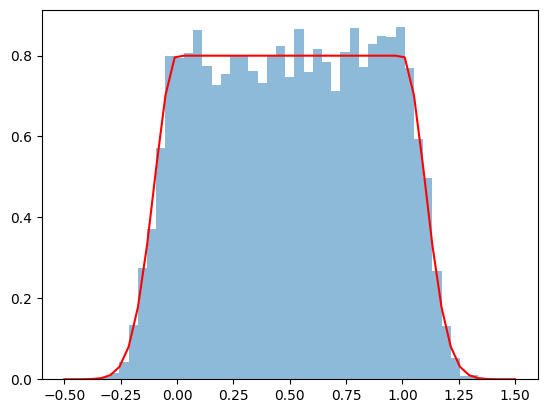

In [28]:
_x = np.linspace(-0.5, 1.5, 50)
plt.hist(samps, _x, density=True, alpha=0.5, label='Samples')
_y = np.exp(dist.log_prob(torch.tensor(_x, device=device)).cpu().numpy())
plt.plot(_x, _y, label='PDF', color='red')

In [ ]:
def simulator(params):
    # simulate stellar brightness over time
    time = np.arange(10)
    brightness = 2 * params[0] * np.exp(-time/5) + params[1] * \
        np.cos(0.5 * time) - 0.8 * params[2] * time**0.5
    brightness += np.random.randn(len(time)) * 0.1
    return brightness

In [ ]:
# LHS sampling function
def lhs_sample_uniform(low, high, n_samples, seed=None):
    """Sample from Uniform distribution using Latin Hypercube Sampling"""
    n_dims = len(low)

    # Generate LHS samples in [0,1]^d
    sampler = qmc.LatinHypercube(d=n_dims, seed=seed)
    u_samples = sampler.random(n=n_samples)

    # Transform to uniform distribution
    samples = torch.from_numpy(u_samples).float()
    for i in range(n_dims):
        samples[:, i] = low[i] + samples[:, i] * (high[i] - low[i])

    return samples


def lhs_sample_tailed_normal(distribution, n_samples, seed=None):
    """Sample from TailedNormal distribution using Latin Hypercube Sampling"""
    n_dims = len(distribution.a)
    a_vals = distribution.a
    b_vals = distribution.b
    sigma_vals = distribution.sigma

    # Generate LHS samples in [0,1]^d
    sampler = qmc.LatinHypercube(d=n_dims, seed=seed)
    u_samples = sampler.random(n=n_samples)

    # Convert to torch tensor
    u_tensor = torch.from_numpy(u_samples).float()

    # Apply inverse CDF for each dimension
    samples = torch.zeros_like(u_tensor)
    for i in range(n_dims):
        # Create 1D distribution for this dimension
        dim_dist = TailedNormal(
            a=a_vals[i],
            b=b_vals[i],
            sigma=sigma_vals[i]
        )
        samples[:, i] = dim_dist.icdf(u_tensor[:, i])

    return samples

In [ ]:
n_simulations = 2000

# Parameters ranges
param_1_range = (0, 2)
param_2_range = (0, 2)
param_3_range = (0, 2)
param_ranges = [param_1_range, param_2_range, param_3_range]

param_1_width = param_1_range[1] - param_1_range[0]
param_2_width = param_2_range[1] - param_2_range[0]
param_3_width = param_3_range[1] - param_3_range[0]

# Scale sigma relative to parameter ranges
sigma_scale = 0.1
sigmas = [sigma_scale * (high - low) for low, high in param_ranges]

# Prior and posterior
prior = ili.utils.IndependentNormal(
    loc=[(param_1_range[1] - param_1_range[0])/2, (param_2_range[1] -
                                                   param_2_range[0])/2, (param_3_range[1] - param_3_range[0])/2],
    scale=[(param_1_range[1] - param_1_range[0])/2, (param_2_range[1] - param_2_range[0])/2, (param_3_range[1] - param_3_range[0])/2], device=device)

proposal_old = ili.utils.Uniform(
    low=[param_1_range[0], param_2_range[0], param_3_range[0]],
    high=[param_1_range[1], param_2_range[1], param_3_range[1]],
    device=device)

# Create the TailedNormal distribution
proposal_new = TailedNormal(
    a=torch.tensor([param_1_range[0], param_2_range[0],
                   param_3_range[0]], dtype=torch.float32),
    b=torch.tensor([param_1_range[1], param_2_range[1],
                   param_3_range[1]], dtype=torch.float32),
    sigma=torch.tensor([sigmas[0], sigmas[1], sigmas[2]], dtype=torch.float32),
)

# theta_old = proposal_old.sample((n_simulations,))
# theta = proposal_new.sample((n_simulations,))

# Sample using LHS
theta_old = lhs_sample_uniform(
    low=[param_1_range[0], param_2_range[0], param_3_range[0]],
    high=[param_1_range[1], param_2_range[1], param_3_range[1]],
    n_samples=n_simulations,
    seed=42
)

theta = lhs_sample_tailed_normal(
    distribution=proposal_new,
    n_samples=n_simulations,
    seed=42
)

# Run simulations for each parameter set
x_old = np.array([simulator(t) for t in theta_old])
x = np.array([simulator(t) for t in theta])

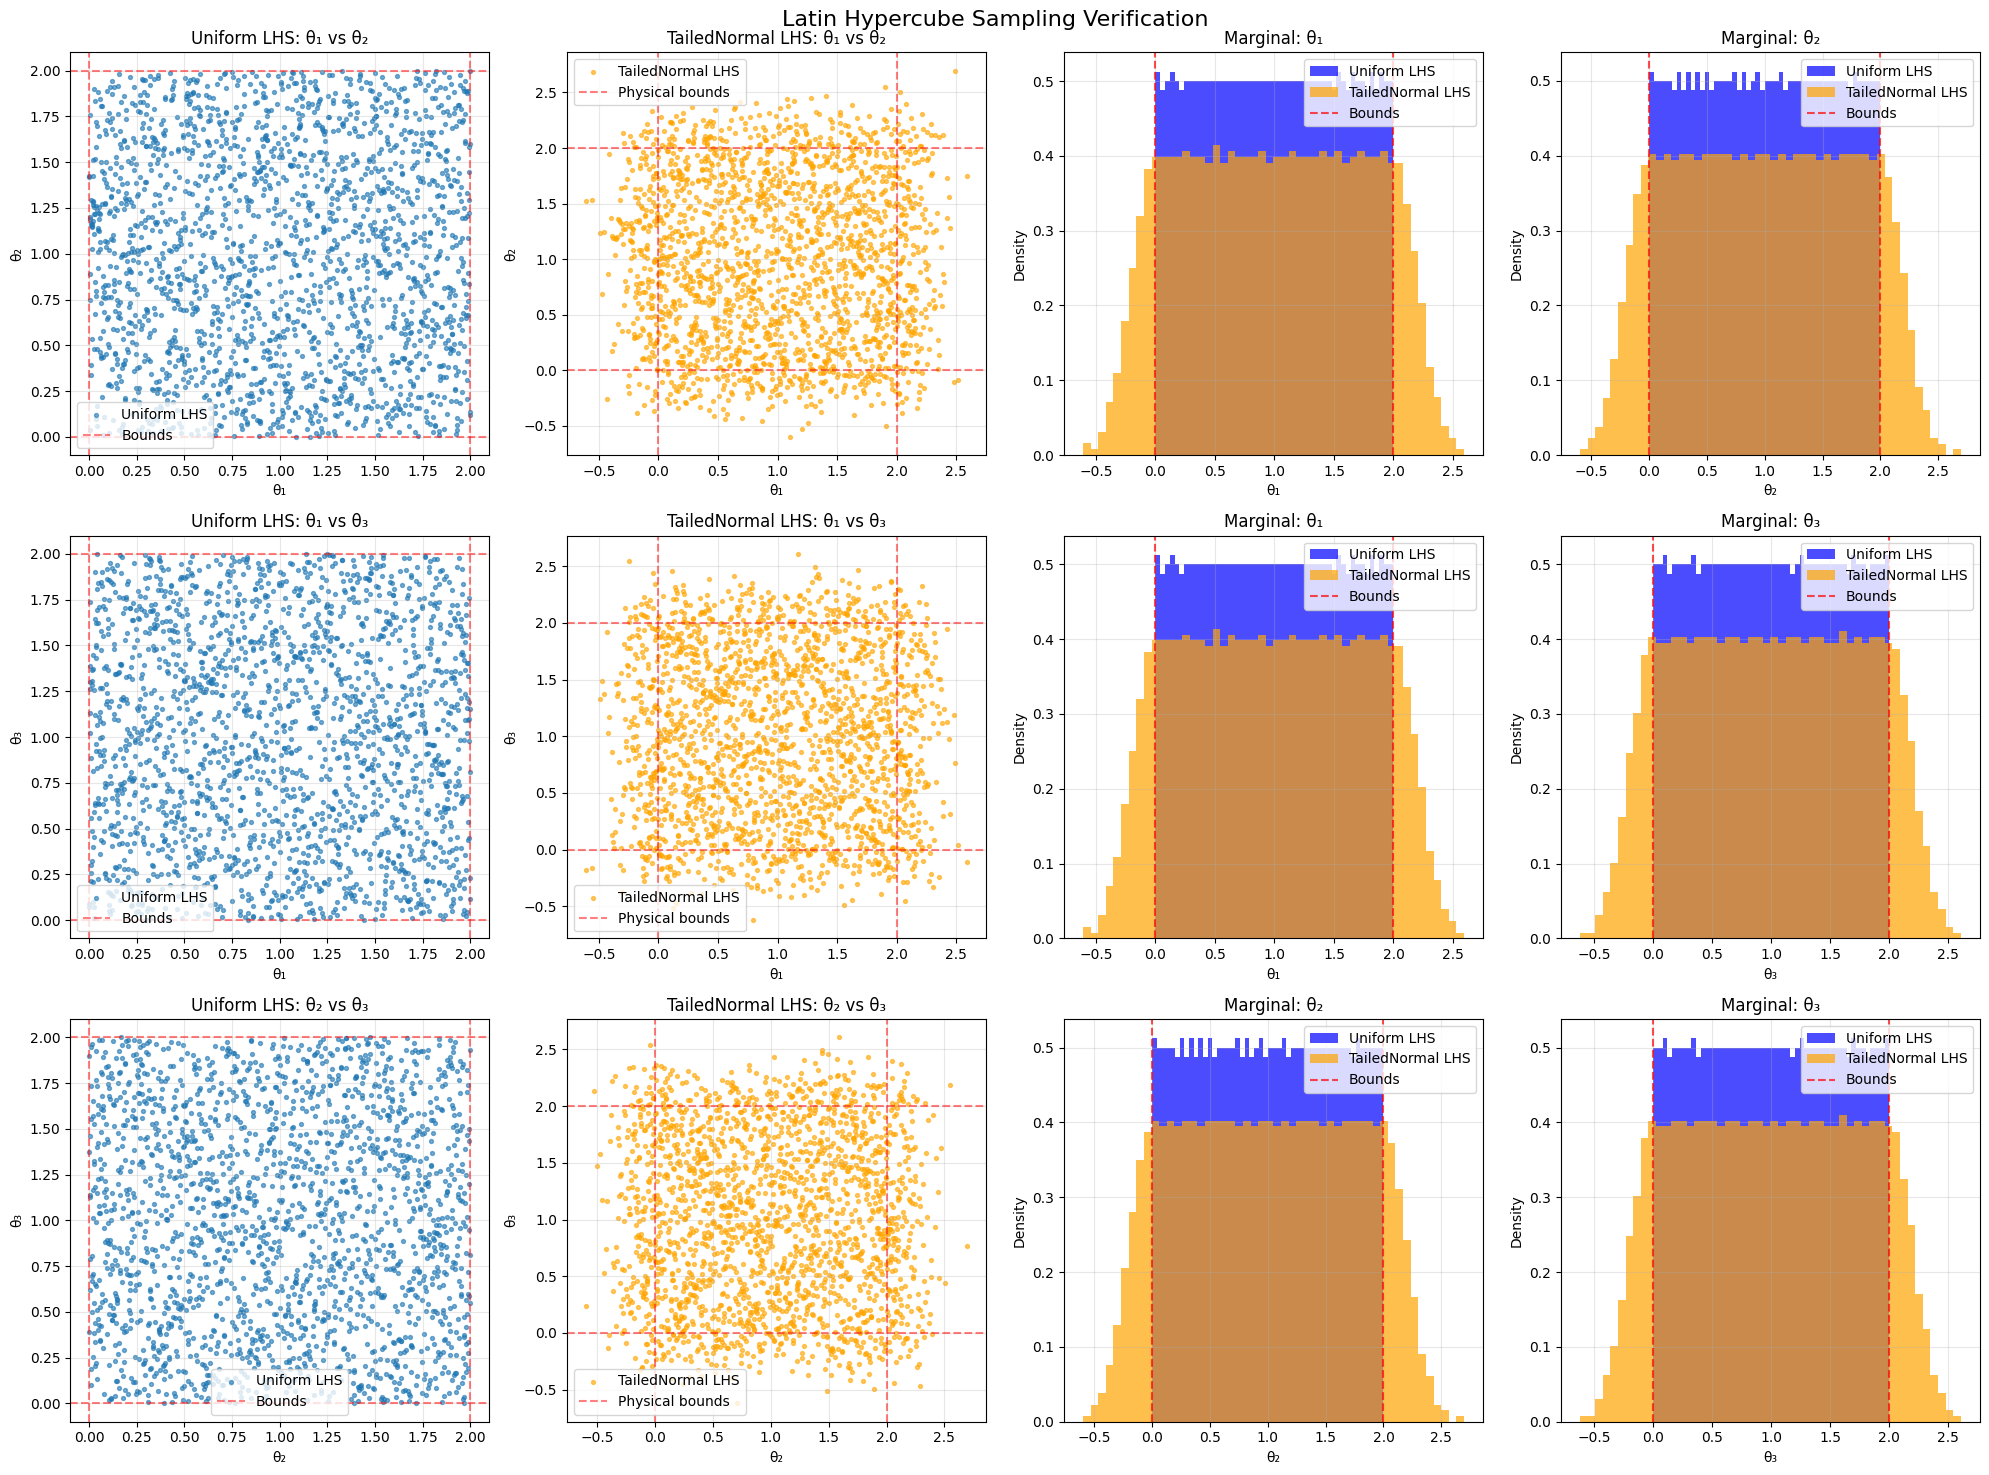

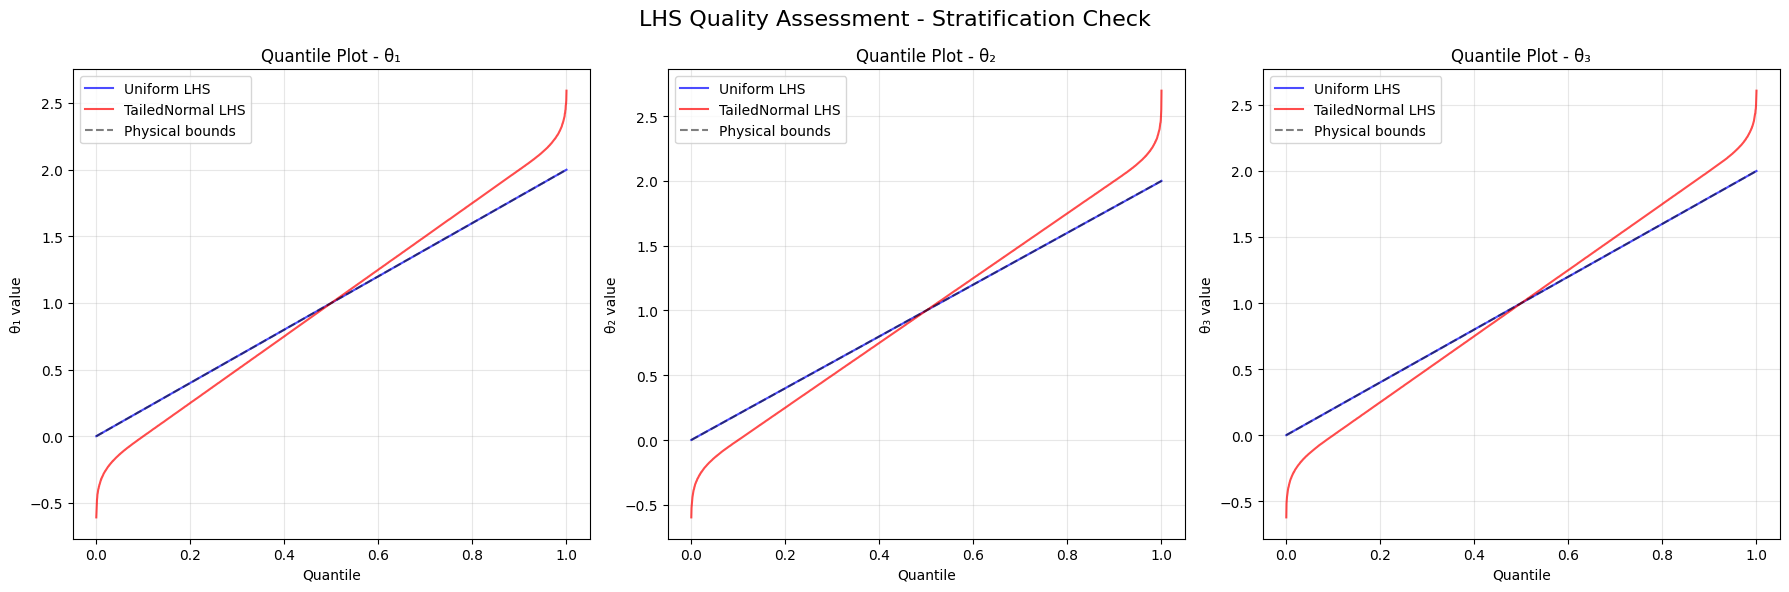

In [ ]:
def plot_lhs_verification(theta_old, theta, param_ranges, n_simulations=2000):
    """
    Create comprehensive plots to verify LHS sampling
    """

    fig = plt.figure(figsize=(20, 15))

    # 1. Parameter space coverage - 2D projections
    fig.suptitle('Latin Hypercube Sampling Verification', fontsize=16, y=0.98)

    # Create subplots for pairwise parameter plots
    param_pairs = [(0, 1), (0, 2), (1, 2)]
    param_names = ['θ₁', 'θ₂', 'θ₃']

    for i, (p1, p2) in enumerate(param_pairs):
        # Uniform LHS
        ax1 = plt.subplot(3, 4, i*4 + 1)
        plt.scatter(theta_old[:, p1], theta_old[:, p2],
                    alpha=0.6, s=8, label='Uniform LHS')
        plt.axvline(param_ranges[p1][0], color='red',
                    linestyle='--', alpha=0.5, label='Bounds')
        plt.axvline(param_ranges[p1][1], color='red', linestyle='--', alpha=0.5)
        plt.axhline(param_ranges[p2][0], color='red', linestyle='--', alpha=0.5)
        plt.axhline(param_ranges[p2][1], color='red', linestyle='--', alpha=0.5)
        plt.xlabel(param_names[p1])
        plt.ylabel(param_names[p2])
        plt.title(f'Uniform LHS: {param_names[p1]} vs {param_names[p2]}')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # TailedNormal LHS
        ax2 = plt.subplot(3, 4, i*4 + 2)
        plt.scatter(theta[:, p1], theta[:, p2], alpha=0.6, s=8,
                    label='TailedNormal LHS', color='orange')
        plt.axvline(param_ranges[p1][0], color='red',
                    linestyle='--', alpha=0.5, label='Physical bounds')
        plt.axvline(param_ranges[p1][1], color='red', linestyle='--', alpha=0.5)
        plt.axhline(param_ranges[p2][0], color='red', linestyle='--', alpha=0.5)
        plt.axhline(param_ranges[p2][1], color='red', linestyle='--', alpha=0.5)
        plt.xlabel(param_names[p1])
        plt.ylabel(param_names[p2])
        plt.title(f'TailedNormal LHS: {param_names[p1]} vs {param_names[p2]}')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Marginal distributions
        ax3 = plt.subplot(3, 4, i*4 + 3)
        plt.hist(theta_old[:, p1], bins=50, alpha=0.7,
                 density=True, label='Uniform LHS', color='blue')
        plt.hist(theta[:, p1], bins=50, alpha=0.7, density=True,
                 label='TailedNormal LHS', color='orange')
        plt.axvline(param_ranges[p1][0], color='red',
                    linestyle='--', alpha=0.7, label='Bounds')
        plt.axvline(param_ranges[p1][1], color='red', linestyle='--', alpha=0.7)
        plt.xlabel(param_names[p1])
        plt.ylabel('Density')
        plt.title(f'Marginal: {param_names[p1]}')
        plt.legend()
        plt.grid(True, alpha=0.3)

        ax4 = plt.subplot(3, 4, i*4 + 4)
        plt.hist(theta_old[:, p2], bins=50, alpha=0.7,
                 density=True, label='Uniform LHS', color='blue')
        plt.hist(theta[:, p2], bins=50, alpha=0.7, density=True,
                 label='TailedNormal LHS', color='orange')
        plt.axvline(param_ranges[p2][0], color='red',
                    linestyle='--', alpha=0.7, label='Bounds')
        plt.axvline(param_ranges[p2][1], color='red', linestyle='--', alpha=0.7)
        plt.xlabel(param_names[p2])
        plt.ylabel('Density')
        plt.title(f'Marginal: {param_names[p2]}')
        plt.legend()
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 2. LHS quality metrics
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('LHS Quality Assessment - Stratification Check', fontsize=16)

    # Check stratification in each dimension
    for i in range(3):
        ax = axes[i]

        # Sort samples to check stratification
        sorted_uniform = np.sort(theta_old[:, i])
        sorted_tailed = np.sort(theta[:, i])

        # Expected quantiles for perfect LHS
        expected_quantiles = np.linspace(0, 1, n_simulations)

        ax.plot(expected_quantiles, sorted_uniform,
                'b-', alpha=0.7, label='Uniform LHS')
        ax.plot(expected_quantiles, sorted_tailed, 'r-',
                alpha=0.7, label='TailedNormal LHS')
        ax.plot([0, 1], [param_ranges[i][0], param_ranges[i][1]],
                'k--', alpha=0.5, label='Physical bounds')

        ax.set_xlabel('Quantile')
        ax.set_ylabel(f'{param_names[i]} value')
        ax.set_title(f'Quantile Plot - {param_names[i]}')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_tail_behavior(proposal_new, param_ranges, n_test=1000):
    """
    Specifically examine the tail behavior of TailedNormal distribution
    """

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('TailedNormal Tail Behavior Analysis', fontsize=16)

    param_names = ['θ₁', 'θ₂', 'θ₃']

    for i in range(3):
        ax = axes[i]

        # Create 1D distribution for this parameter
        single_dist = TailedNormal(
            a=proposal_new.a[i],
            b=proposal_new.b[i],
            sigma=proposal_new.sigma[i]
        )

        # Generate test points
        x_range = torch.linspace(
            param_ranges[i][0] - 0.5,
            param_ranges[i][1] + 0.5,
            1000
        )

        # Calculate log probabilities
        log_probs = single_dist.log_prob(x_range)
        probs = torch.exp(log_probs)

        # Plot
        ax.plot(x_range, probs, 'b-', linewidth=2, label='TailedNormal PDF')
        ax.axvline(param_ranges[i][0], color='red',
                   linestyle='--', alpha=0.7, label='Physical bounds')
        ax.axvline(param_ranges[i][1], color='red', linestyle='--', alpha=0.7)
        ax.fill_between(x_range, 0, probs, alpha=0.3)

        # Highlight tail regions
        left_tail = x_range < param_ranges[i][0]
        right_tail = x_range > param_ranges[i][1]

        ax.fill_between(x_range[left_tail], 0, probs[left_tail],
                        alpha=0.5, color='orange', label='Left tail')
        ax.fill_between(x_range[right_tail], 0, probs[right_tail],
                        alpha=0.5, color='green', label='Right tail')

        ax.set_xlabel(param_names[i])
        ax.set_ylabel('Probability Density')
        ax.set_title(f'{param_names[i]} Distribution')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_yscale('log')

    plt.tight_layout()
    plt.show()


def compare_sampling_methods(param_ranges, n_simulations=2000):
    """
    Compare random vs LHS sampling for both distributions
    """

    # Generate samples using different methods
    seed = 42

    # Random sampling
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Uniform random
    theta_uniform_random = torch.zeros(n_simulations, 3)
    for i in range(3):
        theta_uniform_random[:, i] = torch.rand(
            n_simulations) * (param_ranges[i][1] - param_ranges[i][0]) + param_ranges[i][0]

    # TailedNormal random
    proposal_new = TailedNormal(
        a=torch.tensor([param_ranges[i][0] for i in range(3)]),
        b=torch.tensor([param_ranges[i][1] for i in range(3)]),
        sigma=torch.tensor(
            [0.1 * (param_ranges[i][1] - param_ranges[i][0]) for i in range(3)]),
    )
    theta_tailed_random = proposal_new.sample((n_simulations,))

    # LHS sampling (using your functions)
    theta_uniform_lhs = lhs_sample_uniform(
        low=[param_ranges[i][0] for i in range(3)],
        high=[param_ranges[i][1] for i in range(3)],
        n_samples=n_simulations,
        seed=seed
    )

    theta_tailed_lhs = lhs_sample_tailed_normal(
        distribution=proposal_new,
        n_samples=n_simulations,
        seed=seed
    )

    # Plot comparison
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Random vs LHS Sampling Comparison', fontsize=16)

    # Focus on 2D projection (θ₁, θ₂)
    methods = [
        (theta_uniform_random, 'Uniform Random', 'blue'),
        (theta_uniform_lhs, 'Uniform LHS', 'darkblue'),
        (theta_tailed_random, 'TailedNormal Random', 'orange'),
        (theta_tailed_lhs, 'TailedNormal LHS', 'red')
    ]

    for i, (samples, label, color) in enumerate(methods):
        ax = axes[i//2, i % 2]
        ax.scatter(samples[:, 0], samples[:, 1], alpha=0.6,
                   s=8, color=color, label=label)
        ax.axvline(param_ranges[0][0], color='red', linestyle='--', alpha=0.5)
        ax.axvline(param_ranges[0][1], color='red', linestyle='--', alpha=0.5)
        ax.axhline(param_ranges[1][0], color='red', linestyle='--', alpha=0.5)
        ax.axhline(param_ranges[1][1], color='red', linestyle='--', alpha=0.5)
        ax.set_xlabel('θ₁')
        ax.set_ylabel('θ₂')
        ax.set_title(label)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Run all verification plots
plot_lhs_verification(theta_old, theta, param_ranges, n_simulations)
# plot_tail_behavior(proposal_new, param_ranges)
# compare_sampling_methods(param_ranges, n_simulations)

In [ ]:
import sbibm

# Load the simulator
task = sbibm.get_task("gaussian_linear_uniform", dim=2)
prior = task.get_prior()
simulator = task.get_simulator()

# Generate training data
thetas = prior(num_samples=1_000)
xs = simulator(thetas)

# Display shapes of thetas and xs
thetas.shape, xs.shape

(torch.Size([1000, 2]), torch.Size([1000, 2]))

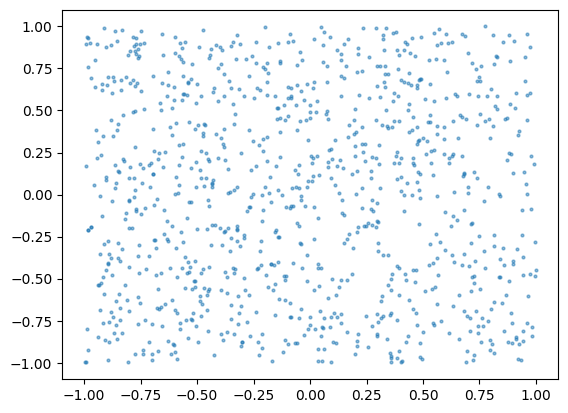

In [ ]:
# plt.plot(xs[:, 0], xs[:, 1], 'o', markersize=2, alpha=0.5)
plt.plot(thetas[:, 0], thetas[:, 1], 'o', markersize=2, alpha=0.5)